## 10.01 注意力提示

### 环境配置

In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import torch
    import torch_npu
    import logging

logging.getLogger("torch_npu").setLevel(logging.WARNING)
import matplotlib.pyplot as plt
from src.utils import show_heatmaps

### 练习 10.1.1

**题目：** 在机器翻译中通过解码序列词元时，其自主性提示可能是什么？非自主性提示和感官输入又是什么？

**解答：** 在机器翻译中，解码器每个时间步要预测下一个输出词元时：

- **自主性提示（查询）**：解码器当前的隐状态（或待预测位置的上下文表示），它携带了解码器"想要生成什么"的主观意图；
- **非自主性提示（键）**：编码器在各个输入位置产生的隐状态（编码序列的每个词元都对应一个键），它们作为输入序列中的客观信息引导查询去"匹配"；
- **感官输入（值）**：与键配对的编码器隐状态（与键相同），注意力汇聚根据查询与键的匹配程度，有选择地聚合这些值，为当前解码步提供上下文信息。

这正是 [10.4 节](../10.04_bahdanau_attention.ipynb) Bahdanau 注意力与 [10.7 节](../10.07_transformer.ipynb) Transformer 中"编码器－解码器"注意力所采用的设计。

### 练习 10.1.2

**题目：** 随机生成一个$10 \times 10$矩阵并使用`softmax`运算来确保每行都是有效的概率分布，然后可视化输出注意力权重。

**解答：** 对每行做 softmax 后，每行元素非负且和为 1，因此可视为 10 个查询分别在 10 个键上的注意力权重分布。以下使用 PyTorch 生成并可视化：

每行和为 1： tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


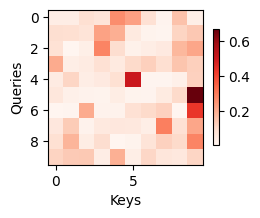

In [2]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
torch.manual_seed(0)
scores = torch.randn(10, 10)
attention_weights = torch.softmax(scores, dim=1)
print('每行和为 1：', attention_weights.sum(dim=1))
show_heatmaps(attention_weights.reshape((1, 1, 10, 10)),
              xlabel='Keys', ylabel='Queries')

---

## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
